In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import numpy as np

from data_preparer import DataPreparer
from allocator import Allocator

from tqdm import tqdm

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
my_allocator = Allocator() 
trade_start_date = "2023-02-01"
preparer = DataPreparer(
    data_path="cold_data/description_vectors.pkl",
    textual_path="cold_data/textual_information.csv",
    stock2idPath="cold_data/stock2id.csv",
    stockDataPath="cold_data/stock_data.csv"
)

In [3]:
final_return, cumulative_returns, weights_history, rebalance_dates = my_allocator.calculate_rebalanced_returns(
    stockData=preparer.stockData[preparer.stockData.index >"2023-01-01"],
    startDate=trade_start_date,
    initial_investment=100000,
    rebalance_dates=['2023-05-19', '2023-06-11',
       '2023-07-04', '2023-07-27', '2023-08-19', '2023-09-11',
       '2023-10-04', '2023-10-27', '2023-11-19', '2023-12-12',
       '2024-01-04', '2024-01-27', '2024-02-19']
)

You must convert self.cov to a positive definite matrix
You must convert self.cov to a positive definite matrix
You must convert self.cov to a positive definite matrix
You must convert self.cov to a positive definite matrix
You must convert self.cov to a positive definite matrix
You must convert self.cov to a positive definite matrix
You must convert self.cov to a positive definite matrix


In [4]:
print("Final Return:", final_return)

Final Return: 0.3378776802488262


In [5]:
rebalance_dates

['2023-05-19',
 '2023-07-27',
 '2023-09-11',
 '2023-10-04',
 '2023-10-27',
 '2023-12-12',
 '2024-01-04']

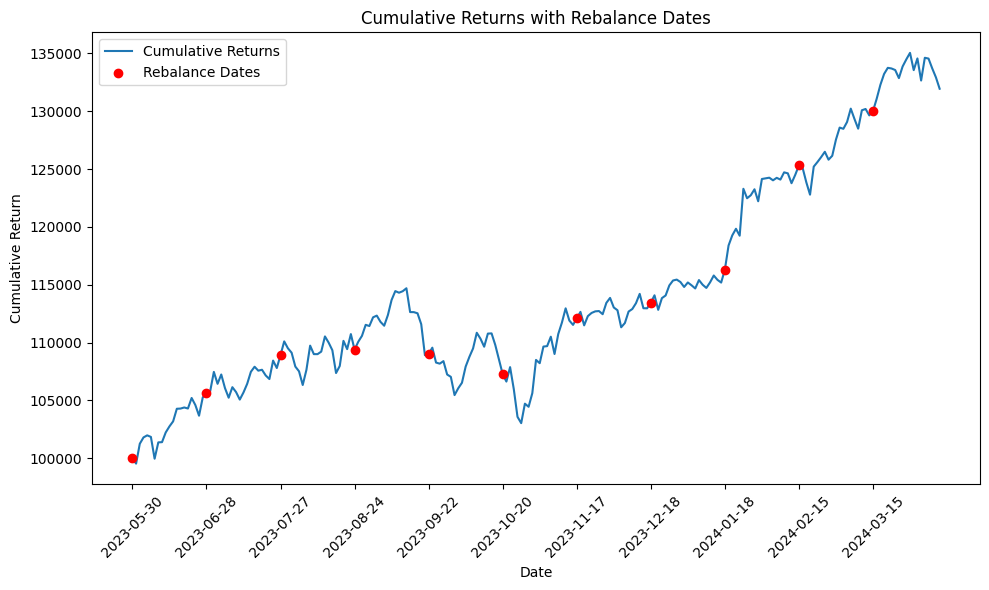

In [11]:
plt.figure(figsize=(10, 6))

# Plot the cumulative returns with all dates (it could be for every day)
plt.plot(cumulative_returns.index, cumulative_returns, label="Cumulative Returns")

# Mark the rebalance dates on the plot
plt.scatter(rebalance_dates, cumulative_returns.loc[rebalance_dates], color='red', label="Rebalance Dates", zorder=5)

# Customizing the x-axis to show only rebalance dates
plt.xticks(rebalance_dates, rotation=45)

# Adding labels and title
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Cumulative Returns with Rebalance Dates")
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

# Proposed Method

In [12]:
def get_filtered_universe(preparer_obj, ts, tx, threshold, snapshot_start_id=0, snapshot_end_id=5):
    preparer_obj.prepare_snapshots(weight_combination={"ts":ts, "tx":tx}, threshold=threshold)
    preparer_obj.calculate_similarity_matrix(node_count=200, snapshot_start_id=snapshot_start_id, snapshot_end_id=snapshot_end_id)
    preparer_obj.calculate_final_communes()
    node_metrics = preparer_obj.calculate_node_metrics()
    node_metrics["stock"] = preparer.stock2id.index
    
    centrality_threshold = node_metrics.centrality.mean()
    investment_universe = node_metrics.reset_index()[(node_metrics.centrality < centrality_threshold)]
    pagerank_threshold = investment_universe.pagerank.mean() + investment_universe.pagerank.std() / 2
    investment_universe = investment_universe[(investment_universe.pagerank > pagerank_threshold)]
    
    return investment_universe.stock

In [13]:
with open("calculated_data/historical_ts_sim_pearson.pkl", "rb") as f:
        ts_sim = pickle.load(f)

combinations = [{"id":0, "ts": 0.55, "tx": 0.45}]

In [14]:
my_allocator = Allocator(rebalancing_period=20)

In [15]:
rebalance_dates = []
available_dates = list(ts_sim.keys())
ts, tx, threshold = 0.45, 0.55, 0.3

for i in range(len(available_dates)-6):
    start_id = i
    end_id = i+6
    if end_id > len(available_dates):
        end_id = len(available_dates)

    rebalance_dates.append([start_id, end_id])


In [17]:
filtered_sims = {}    
selected_stock_history = []
optimization_history = []

for reb_date_id in tqdm(rebalance_dates):
    for k in available_dates[reb_date_id[0]:reb_date_id[1]]:
        filtered_sims[k] = ts_sim[k]

    preparer.ts_similarities = filtered_sims

    selected_stocks = get_filtered_universe(preparer, ts, tx, threshold=threshold, snapshot_start_id=0, snapshot_end_id=5)
    filtered_optim = my_allocator.mean_variance_optimization(
        preparer.stockData[(preparer.stockData.index < available_dates[end_id][0]) & 
            (preparer.stockData.index > "2023-01-01")][selected_stocks], min_weight=0.01, take_pct_change=True
        )

    selected_stock_history.append((available_dates[end_id][0], selected_stocks))
    optimization_history.append((available_dates[end_id][0], filtered_optim))

100%|██████████| 13/13 [03:25<00:00, 15.82s/it]


In [30]:
np.array(list(ts_sim.keys()))[:, 0]

array(['2023-01-01', '2023-01-24', '2023-02-16', '2023-03-11',
       '2023-04-03', '2023-04-26', '2023-05-19', '2023-06-11',
       '2023-07-04', '2023-07-27', '2023-08-19', '2023-09-11',
       '2023-10-04', '2023-10-27', '2023-11-19', '2023-12-12',
       '2024-01-04', '2024-01-27', '2024-02-19'], dtype='<U10')

In [19]:
returnbydate = {}
for idx, reb_date_id in tqdm(enumerate(rebalance_dates)):
    last_end_id = rebalance_dates[-1][1]
    start_id, end_id = reb_date_id[0], reb_date_id[1]

    optim = optimization_history[idx][1]
    if end_id != last_end_id:
        stock_data = preparer.stockData[(preparer.stockData.index < available_dates[end_id+1][0])]
    else:
        stock_data = preparer.stockData

    start_date = preparer.stockData[(preparer.stockData.index < available_dates[end_id][0])].index[-1]

    filtered_return = my_allocator.calculate_cumulative_return(
                optim[optim.weights > 0], 
                stockData=stock_data,
                startDate=start_date
            )
    
    returnbydate[(start_date, stock_data.index[-1])] = filtered_return[0]

13it [00:00, 24.02it/s]


In [20]:
cumulative = 1.0
for period_return in returnbydate.values():
    cumulative *= (1 + period_return)
    total_return = cumulative - 1

print("Total Return:", total_return)

Total Return: 0.6104270504608187


In [22]:
rebalance_dates

[[0, 6],
 [1, 7],
 [2, 8],
 [3, 9],
 [4, 10],
 [5, 11],
 [6, 12],
 [7, 13],
 [8, 14],
 [9, 15],
 [10, 16],
 [11, 17],
 [12, 18]]